# Notebook Fusion — Pipeline complet

Ce notebook regroupe l'ensemble du travail :
1. **Transformation des donnees** (KNN imputation, nettoyage outliers, normalisation Z-Score)
2. **Random Forest Classifier** (donnees non normalisees)
3. **Perceptron Multi-Couches (MLP Classifier)** (donnees normalisees)
4. **Interpretabilite** (SHAP pour le MLP, importance MDI pour le Random Forest)
5. **Etude comparative** (matrices de confusion, ROC, precision/recall/F1, temps d'execution)

### Objectif : interpretabilite et explicabilite

L'enjeu central de ce notebook est de **comprendre pourquoi** les modeles prennent leurs decisions, pas seulement de mesurer leur performance. On distingue :

- **Interpretabilite** : capacite a comprendre le mecanisme interne du modele. Un arbre de decision est interpretable par nature (on suit les splits). Un reseau de neurones ne l'est pas.
- **Explicabilite** : capacite a fournir des explications *a posteriori* sur les predictions, meme pour un modele opaque. C'est le role de SHAP.

Le Random Forest est entraine sur des donnees **non normalisees** pour que les seuils de decision soient lisibles en unites reelles. Le MLP, qui a besoin de normalisation pour converger, est explique via SHAP.

---
# PARTIE 1 — Pipeline de transformation des donnees

**Source** : `housing.csv` (donnees brutes) → **Sortie** : `amputed_normalized_housing_data.csv`

| Etape | Operation | Detail |
|-------|-----------|--------|
| 1 | Imputation KNN | `total_bedrooms` — 207 NaN combles par $k=5$ voisins ponderes par distance |
| 2 | Encodage ordinal | `ocean_proximity` → 0–4 |
| 3 | Nettoyage outliers | Suppression prix plafonnes (500 001$) + IQR sur features numeriques |
| 4 | Normalisation Z-Score | $z = \frac{x - \mu}{\sigma}$ — appliquee uniquement pour le MLP. Le Random Forest utilise les donnees non normalisees pour une meilleure interpretabilite. |

In [76]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

housing = pd.read_csv('./datasets/housing.csv')
print(f"Shape : {housing.shape}")
print(f"Valeurs manquantes : total_bedrooms → {housing['total_bedrooms'].isnull().sum()}")

Shape : (20640, 10)
Valeurs manquantes : total_bedrooms → 207


## 1. Imputation KNN ($k=5$, ponderation par distance)

### Pourquoi KNN pour l'imputation ?

Lorsqu'une colonne contient des valeurs manquantes (ici `total_bedrooms` avec 207 NaN), on peut soit supprimer les lignes, soit les imputer. La suppression perd de l'information ; l'imputation par la moyenne ignore les relations entre variables.

L'**imputation KNN** est plus fine : pour chaque valeur manquante, elle identifie les $k$ observations les plus proches (au sens de la distance euclidienne sur les autres features) et calcule une moyenne ponderee par l'inverse de la distance :

$$\hat{x}_i = \frac{\sum_{j \in \mathcal{N}_k(i)} w_j \cdot x_j}{\sum_{j \in \mathcal{N}_k(i)} w_j}, \quad w_j = \frac{1}{d(i,j)}$$

Les voisins proches ont un poids plus fort — l'intuition est qu'un logement similaire (meme localisation, meme taille, meme revenu) a probablement un nombre de chambres similaire.

**Standardisation temporaire** : avant le KNN, on standardise les features pour que la distance euclidienne soit coherente (sinon `population` dominerait `latitude` par sa magnitude). Apres imputation, on de-standardise pour retrouver les valeurs reelles.

In [77]:
# Encodage temporaire de ocean_proximity pour KNN (numérique requis)
ocean_mapping = {'<1H OCEAN': 0, 'INLAND': 1, 'ISLAND': 2, 'NEAR BAY': 3, 'NEAR OCEAN': 4}
housing['ocean_proximity'] = housing['ocean_proximity'].map(ocean_mapping)

# Standardisation temporaire → KNN → dé-standardisation
num_cols = housing.columns.tolist()
means, stds = housing[num_cols].mean(), housing[num_cols].std()
X_scaled = (housing[num_cols] - means) / stds

imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_scaled) * stds.values + means.values,
    columns=num_cols, index=housing.index
)
housing['total_bedrooms'] = X_imputed['total_bedrooms'].round(0)

print(f"Valeurs manquantes après imputation : {housing.isnull().sum().sum()}")

Valeurs manquantes après imputation : 0


## 2. Nettoyage des outliers

### Pourquoi supprimer les outliers ?

Les valeurs aberrantes peuvent fausser l'apprentissage : un prix artificiellement plafonne ou un bloc avec une population anormalement elevee ne represente pas le comportement general du marche. Le modele risque de sur-apprendre ces cas extremes au detriment de la generalisation.

**2a. Prix plafonnes** (`median_house_value == 500001`) : ces valeurs sont **censurees**, pas des prix reels. Le recensement a plafonne a 500 001$ — on ne connait pas le vrai prix. Les garder biaiserait le modele vers une fausse concentration de prix a ce seuil.

**2b. Methode IQR (Interquartile Range)** : pour chaque feature numerique, on detecte les outliers statistiques :

$$\text{outlier si } x < Q_1 - 1.5 \times IQR \text{ ou } x > Q_3 + 1.5 \times IQR$$

ou $IQR = Q_3 - Q_1$. Le facteur 1.5 est un compromis classique (Tukey, 1977) : il capture ~99.3% des donnees sous hypothese gaussienne. On applique ce filtre sur toutes les features sauf `ocean_proximity` (categorielle) et `median_house_value` (cible).

In [78]:
n_before = len(housing)

# 2a. Suppression des prix plafonnés
capped = (housing['median_house_value'] == 500001).sum()
housing = housing[housing['median_house_value'] != 500001]
print(f"Prix plafonnés supprimés : {capped}")

# 2b. Suppression des outliers IQR sur les features numériques
iqr_cols = [c for c in housing.columns if c not in ('ocean_proximity', 'median_house_value')]
mask = pd.Series(True, index=housing.index)

for col in iqr_cols:
    q1 = housing[col].quantile(0.25)
    q3 = housing[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    col_mask = (housing[col] >= lower) & (housing[col] <= upper)
    n_out = (~col_mask).sum()
    if n_out > 0:
        print(f"  {col:>20s} : {n_out} outliers (bornes [{lower:.1f}, {upper:.1f}])")
    mask &= col_mask

housing = housing[mask].reset_index(drop=True)
n_after = len(housing)
print(f"\nLignes supprimées : {n_before - n_after} ({(n_before - n_after)/n_before*100:.1f}%)")
print(f"Lignes restantes  : {n_after}")

Prix plafonnés supprimés : 965
           total_rooms : 1251 outliers (bornes [-1085.0, 5643.0])
        total_bedrooms : 1227 outliers (bornes [-229.5, 1174.5])
            population : 1126 outliers (bornes [-629.0, 3171.0])
            households : 1165 outliers (bornes [-204.0, 1092.0])
         median_income : 364 outliers (bornes [-0.6, 7.7])

Lignes supprimées : 3039 (14.7%)
Lignes restantes  : 17601


## 3. Normalisation Z-Score (pour le MLP uniquement)

$$z = \frac{x - \mu}{\sigma}$$

### Pourquoi normaliser ?

Le MLP (reseau de neurones) calcule des combinaisons lineaires ponderees des entrees. Si une feature a des valeurs dans les milliers (`population`) et une autre entre -124 et -114 (`longitude`), les gradients seront domines par la feature a grande magnitude, rendant l'optimisation instable et lente.

La normalisation Z-Score centre chaque feature a moyenne 0 et ecart-type 1, mettant toutes les features sur un pied d'egalite pour la descente de gradient.

### Pourquoi ne pas normaliser pour le Random Forest ?

Le Random Forest prend ses decisions par des **splits binaires** (ex. `median_income <= 4.5`). Ces splits sont invariants a toute transformation monotone : normaliser ne change ni l'ordre des observations, ni la qualite des splits. En revanche, garder les valeurs brutes rend les seuils de decision **directement interpretables** en unites reelles — on peut lire « un revenu median > 4.5 pousse vers la classe expensive » au lieu de « z-score > 0.73 ».

`median_house_value` reste en valeur brute dans les deux cas — c'est la variable a partir de laquelle on construit la cible.

In [79]:
# Sauvegarde des données non normalisées (pour Random Forest)
housing_raw = housing.copy()

target = 'median_house_value'
feature_cols = [c for c in housing.columns if c != target]

scaler = StandardScaler()
housing[feature_cols] = scaler.fit_transform(housing[feature_cols])

print("Features normalisées (mean ≈ 0, std ≈ 1) — utilisées par le MLP :")
print(housing[feature_cols].describe().loc[['mean', 'std']].round(4))
print(f"\nmedian_house_value (non transformé) : mean={housing[target].mean():.0f}, std={housing[target].std():.0f}")
print(f"\nDonnées non normalisées conservées pour le Random Forest.")

Features normalisées (mean ≈ 0, std ≈ 1) — utilisées par le MLP :
      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
mean        0.0       0.0                -0.0          0.0             0.0   
std         1.0       1.0                 1.0          1.0             1.0   

      population  households  median_income  ocean_proximity  
mean         0.0        -0.0           -0.0              0.0  
std          1.0         1.0            1.0              1.0  

median_house_value (non transformé) : mean=187322, std=94874

Données non normalisées conservées pour le Random Forest.


## 4. Export

In [80]:
output_path = './datasets/amputed_normalized_housing_data.csv'
housing.to_csv(output_path, index=False)
print(f"Exporté : {output_path} — {housing.shape[0]} lignes, {housing.shape[1]} colonnes")
housing.head()

Exporté : ./datasets/amputed_normalized_housing_data.csv — 17601 lignes, 10 colonnes


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.315977,0.995320,1.83728,-0.622220,-1.156299,-1.161352,-1.168233,2.620165,352100.0,1.300935
1,-1.320967,0.995320,1.83728,-0.799883,-0.953182,-1.058970,-0.964205,1.477758,341300.0,1.300935
2,-1.320967,0.995320,1.83728,-0.474934,-0.750065,-1.047410,-0.769893,0.206130,342200.0,1.300935
3,-1.320967,0.995320,1.83728,-1.126674,-1.052484,-1.298413,-1.090508,0.341013,269700.0,1.300935
4,-1.320967,0.990705,1.83728,0.360912,0.193300,-0.173855,0.468851,0.073723,299200.0,1.300935


---
# Preparation pour la classification

On cree une variable cible binaire `expensive` :
- **1** si `median_house_value` > mediane
- **0** sinon

Deux jeux de donnees sont utilises :
- **Non normalise** → Random Forest (splits interpretables en unites reelles)
- **Normalise (Z-Score)** → MLP (convergence plus rapide)

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
)

# Données normalisées (pour MLP)
df = housing.copy()
# Données non normalisées (pour Random Forest)
df_raw = housing_raw.copy()

# Variable cible binaire (même seuil pour les deux)
median_price = df['median_house_value'].median()
df['expensive'] = (df['median_house_value'] > median_price).astype(int)
df_raw['expensive'] = (df_raw['median_house_value'] > median_price).astype(int)

print(f"Shape : {df.shape}")
print(f"\nDistribution de expensive :\n{df['expensive'].value_counts()}")
print(f"\nSeuil (mediane) : {median_price:.0f}")

Shape : (17601, 11)

Distribution de expensive :
expensive
0    8808
1    8793
Name: count, dtype: int64

Seuil (mediane) : 169800


## Analyse de colinearite

### Pourquoi verifier la colinearite ?

Deux features fortement correlees ($|r| > 0.8$) portent essentiellement la meme information. Les garder toutes les deux :
- **Random Forest** : dilue l'importance entre les deux features correlees (chaque arbre choisit l'une ou l'autre au hasard), rendant l'importance des features moins fiable.
- **MLP** : rend la surface de perte plus plate dans certaines directions, ralentissant la convergence.

On identifie les paires avec $|r| > 0.8$ et on supprime, pour chaque paire, la feature la **moins correlee avec la cible** — celle qui apporte le moins d'information discriminante.

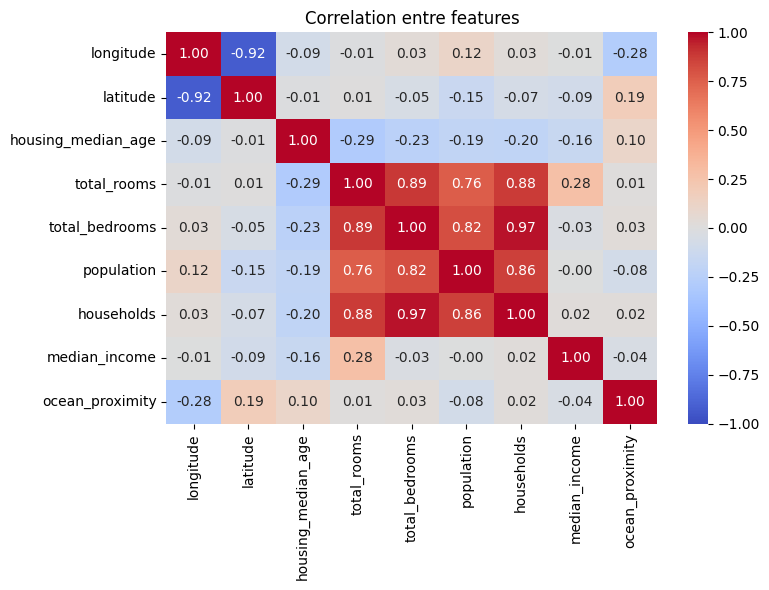

  longitude <-> latitude : r = -0.923
  total_rooms <-> total_bedrooms : r = 0.888
  total_rooms <-> households : r = 0.880
  total_bedrooms <-> population : r = 0.820
  total_bedrooms <-> households : r = 0.971
  population <-> households : r = 0.860


In [82]:
target = 'expensive'
features = [c for c in df.columns if c not in (target, 'median_house_value')]

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation entre features')
plt.tight_layout()
plt.show()

# Paires fortement correlees
threshold = 0.8
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if abs(corr.iloc[i, j]) > threshold:
            pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
            print(f"  {corr.index[i]} <-> {corr.columns[j]} : r = {corr.iloc[i, j]:.3f}")

if not pairs:
    print("Aucune paire avec |r| > 0.8")

In [83]:
# Suppression des features redondantes
target_corr = df[features].corrwith(df[target]).abs()

to_drop = set()
for a, b, r in pairs:
    drop = a if target_corr[a] < target_corr[b] else b
    to_drop.add(drop)
    print(f"  {a} (|r_target|={target_corr[a]:.3f}) vs {b} (|r_target|={target_corr[b]:.3f}) -> drop {drop}")

features_clean = [f for f in features if f not in to_drop]
print(f"\nFeatures conservees ({len(features_clean)}) : {features_clean}")
print(f"Features supprimees ({len(to_drop)}) : {to_drop}")

  longitude (|r_target|=0.020) vs latitude (|r_target|=0.163) -> drop longitude
  total_rooms (|r_target|=0.162) vs total_bedrooms (|r_target|=0.085) -> drop total_bedrooms
  total_rooms (|r_target|=0.162) vs households (|r_target|=0.114) -> drop households
  total_bedrooms (|r_target|=0.085) vs population (|r_target|=0.004) -> drop population
  total_bedrooms (|r_target|=0.085) vs households (|r_target|=0.114) -> drop total_bedrooms
  population (|r_target|=0.004) vs households (|r_target|=0.114) -> drop population

Features conservees (5) : ['latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity']
Features supprimees (4) : {'households', 'longitude', 'population', 'total_bedrooms'}


## Train / Test split (70/30)

On partitionne les donnees en 70% entrainement et 30% test avec un `random_state` fixe pour la reproductibilite. Le meme split est applique simultanement aux donnees normalisees (MLP) et non normalisees (Random Forest), garantissant que les deux modeles sont evalues sur **exactement les memes observations**. Cela rend la comparaison equitable.

In [84]:
X = df[features_clean].values        # normalisé (MLP)
X_raw = df_raw[features_clean].values  # non normalisé (Random Forest)
y = df[target].values

X_train, X_test, X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, X_raw, y, test_size=0.3, random_state=42
)
print(f"Train : {X_train.shape[0]} echantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} echantillons ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nRandom Forest → données non normalisées")
print(f"MLP           → données normalisées (Z-Score)")

Train : 12320 echantillons (70%)
Test  : 5281 echantillons (30%)

Random Forest → données non normalisées
MLP           → données normalisées (Z-Score)


---
# PARTIE 2 — Random Forest Classifier (donnees non normalisees)

### Theorie : le Bagging et la foret aleatoire

Le Random Forest (Breiman, 2001) repose sur deux idees :

1. **Bagging (Bootstrap Aggregating)** : chaque arbre est entraine sur un echantillon bootstrap (tirage avec remise) du jeu d'entrainement. Les arbres voient des sous-ensembles differents des donnees, ce qui les rend **decorrelés**.

2. **Sous-echantillonnage des features** : a chaque split, l'arbre ne considere qu'un sous-ensemble aleatoire de $\sqrt{p}$ features (parmi $p$). Cela empeche qu'une feature dominante (ex. `median_income`) soit systematiquement choisie par tous les arbres.

La prediction finale est le **vote majoritaire** des $B$ arbres :

$$\hat{y} = \text{mode}\big(T_1(x), T_2(x), \ldots, T_B(x)\big)$$

### Pourquoi le Random Forest est interpretable ?

- Chaque arbre est une suite de regles « si/alors » lisibles par un humain.
- L'**importance des features** (MDI) mesure la reduction moyenne d'impurete apportee par chaque variable sur l'ensemble des arbres.
- Les donnees etant **non normalisees**, les seuils de decision (ex. `median_income <= 4.5`) sont directement comprehensibles.

### Reduction de la variance

Un arbre seul a une forte variance (sensible aux donnees d'entrainement). En moyennant $B$ arbres decorrelés, le Random Forest reduit cette variance sans augmenter le biais :

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B T_b\right) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

ou $\rho$ est la correlation moyenne entre arbres et $\sigma^2$ la variance d'un arbre. Le sous-echantillonnage des features reduit $\rho$, et un grand $B$ reduit le second terme.

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train_raw, y_train)

print(f"Nombre d'arbres       : {rf_model.n_estimators}")
print(f"Profondeur max        : {rf_model.max_depth or 'illimitee'}")
print(f"Features par split    : {rf_model.max_features}")
print(f"Nombre de features    : {rf_model.n_features_in_}")
print(f"\n(Entrainé sur données NON normalisées pour une meilleure interprétabilité)")

Nombre d'arbres       : 100
Profondeur max        : illimitee
Features par split    : sqrt
Nombre de features    : 5

(Entrainé sur données NON normalisées pour une meilleure interprétabilité)


### Importance des features (Mean Decrease in Impurity)

L'importance MDI mesure, pour chaque feature, la **reduction totale de l'impurete de Gini** qu'elle apporte en moyenne sur l'ensemble des arbres de la foret :

$$\text{Importance}(f) = \frac{1}{B} \sum_{b=1}^B \sum_{t \in T_b} \mathbb{1}[v(t) = f] \cdot \Delta G(t)$$

ou $\Delta G(t)$ est la reduction de Gini au noeud $t$ et $v(t)$ est la feature utilisee pour le split.

**Comment interpreter** : une feature avec une haute importance MDI est frequemment utilisee par les arbres pour separer les classes, et les splits sur cette feature produisent des noeuds plus purs. Ici, on s'attend a ce que `median_income` domine — le revenu median est le principal determinant du prix immobilier.

Importance des features :
  median_income             : 0.3727
  latitude                  : 0.2187
  ocean_proximity           : 0.1600
  total_rooms               : 0.1392
  housing_median_age        : 0.1093


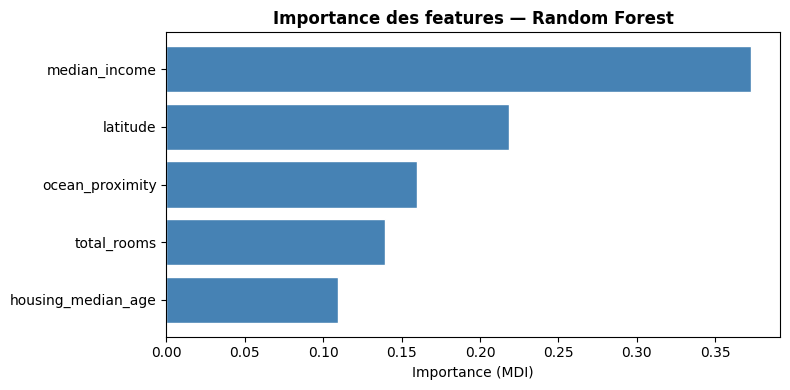

In [86]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Importance des features :")
for i in indices:
    print(f"  {features_clean[i]:25s} : {importances[i]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([features_clean[i] for i in indices[::-1]], importances[indices[::-1]], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (MDI)')
ax.set_title('Importance des features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

### Visualisation d'un arbre individuel

Arbre n°0 de la foret, limite a une profondeur de 3 pour la lisibilite.

**Comment lire l'arbre** :
- Chaque **noeud** contient une condition de split (ex. `median_income <= 4.5`), le nombre d'echantillons (`samples`), et la repartition des classes (`value = [cheap, expensive]`).
- **A gauche** : la condition est vraie (ex. revenu <= 4.5). **A droite** : la condition est fausse.
- La **couleur** indique la classe dominante : bleu pour `cheap`, orange pour `expensive`. Plus la couleur est foncee, plus le noeud est pur.
- Les **feuilles** (noeuds terminaux) donnent la prediction finale du sous-arbre.

Grace aux donnees non normalisees, les seuils sont directement interpretables : « un logement dans un quartier ou le revenu median est inferieur a 4.5 (en dizaines de milliers de dollars) tend a etre classé cheap ».

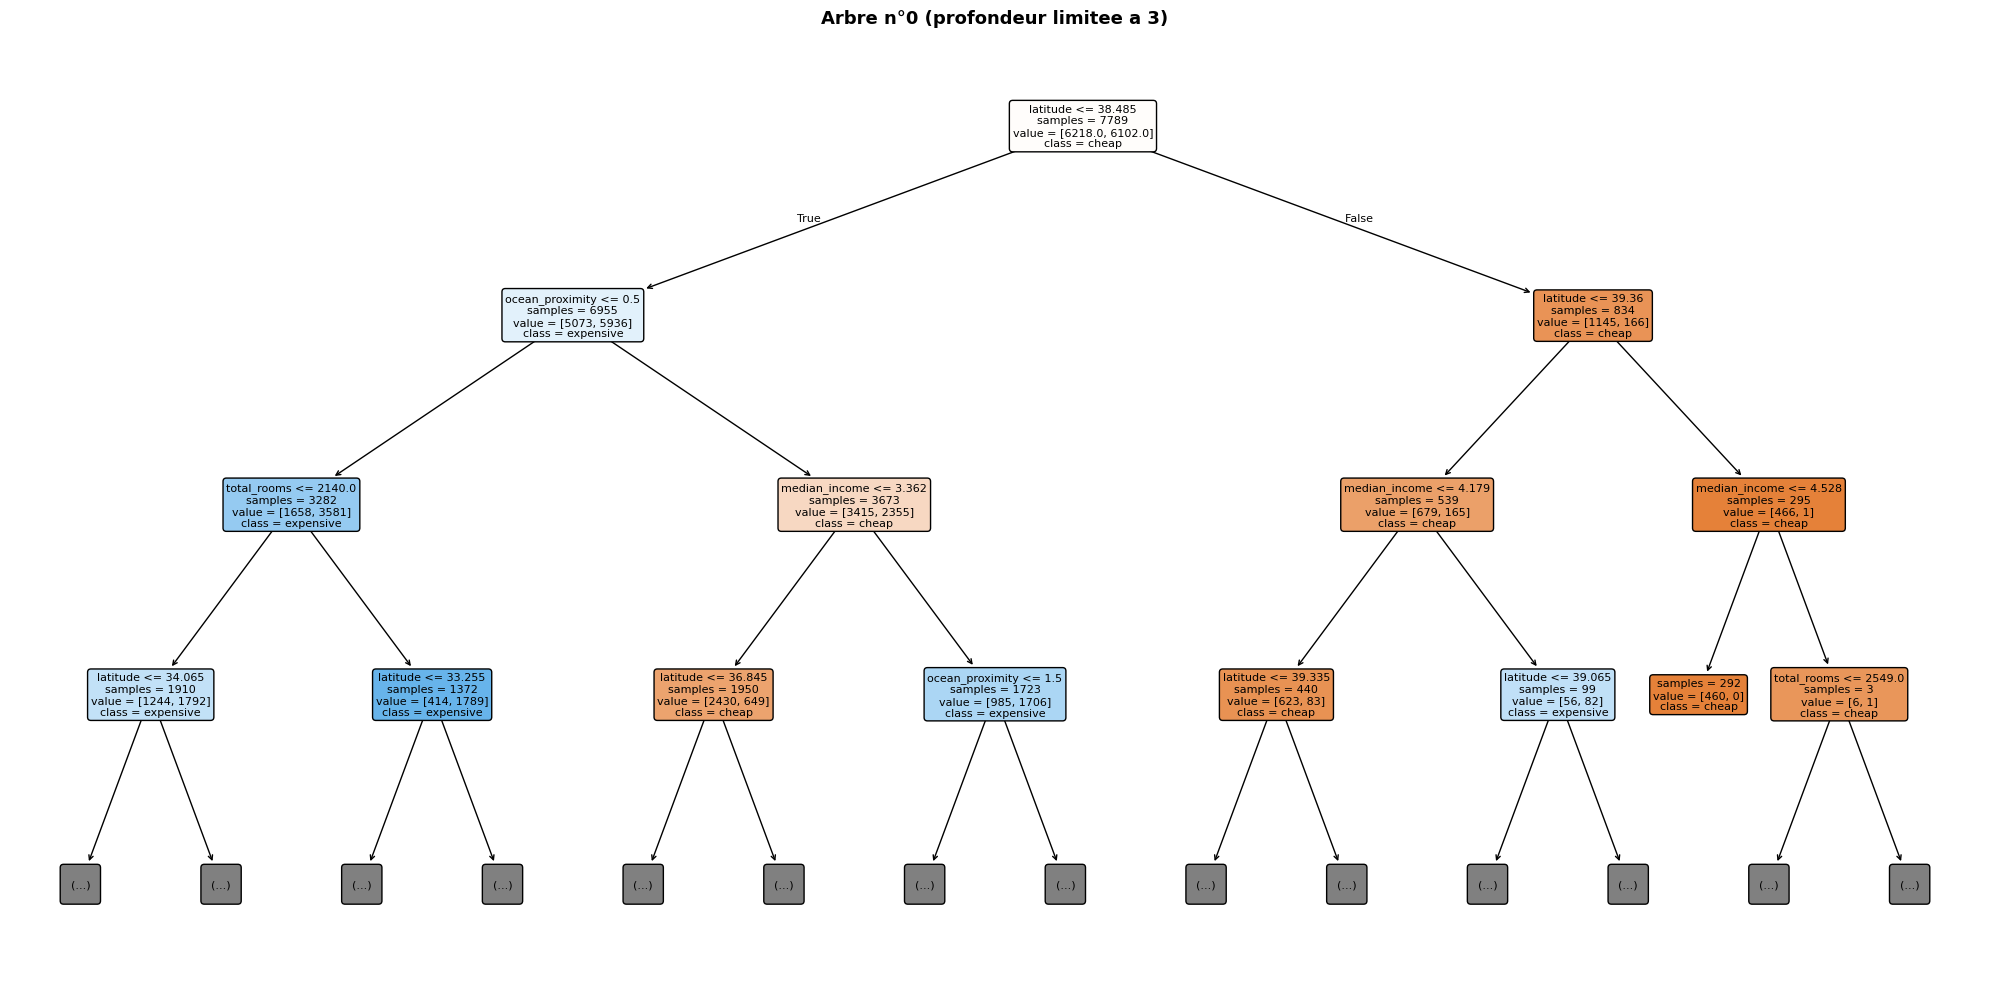

In [87]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0],
    max_depth=3,
    feature_names=features_clean,
    class_names=['cheap', 'expensive'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
)
ax.set_title('Arbre n°0 (profondeur limitee a 3)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Evaluation du Random Forest

**Comment interpreter la matrice de confusion et le rapport de classification** :

- **Precision** (`cheap`) : parmi toutes les predictions « cheap », quel pourcentage est reellement cheap ? Une precision elevee signifie peu de faux positifs.
- **Recall** (`cheap`) : parmi tous les vrais cheap, quel pourcentage est correctement identifie ? Un recall eleve signifie peu de faux negatifs.
- **F1-Score** : moyenne harmonique de precision et recall — un compromis entre les deux.

Un modele equilibre (precision ≈ recall pour les deux classes) est souhaitable ici car les classes sont de taille similaire.

In [88]:
y_pred_rf = rf_model.predict(X_test_raw)

print("Matrice de Confusion (Random Forest) :")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_rf, target_names=['cheap', 'expensive']))

Matrice de Confusion (Random Forest) :
[[2215  415]
 [ 395 2256]]

Rapport de Classification :
              precision    recall  f1-score   support

       cheap       0.85      0.84      0.85      2630
   expensive       0.84      0.85      0.85      2651

    accuracy                           0.85      5281
   macro avg       0.85      0.85      0.85      5281
weighted avg       0.85      0.85      0.85      5281



---
# PARTIE 3 — Perceptron Multi-Couches (MLP)

### Theorie : le reseau de neurones feed-forward

Le MLP est un reseau de neurones a propagation avant (feed-forward). Chaque couche applique une transformation affine suivie d'une fonction d'activation non-lineaire :

$$h^{(l)} = \text{ReLU}(W^{(l)} h^{(l-1)} + b^{(l)})$$
$$\hat{y} = \sigma(W^{(L)} h^{(L-1)} + b^{(L)})$$

- **ReLU** (Rectified Linear Unit) : $\text{ReLU}(x) = \max(0, x)$. Simple, rapide, evite le probleme du gradient evanescent.
- **Softmax** en sortie : convertit les logits en probabilites $\hat{p}(\text{expensive}) \in [0, 1]$.

Architecture : **5 features → 64 neurones → 32 neurones → 2 sorties**

### Pourquoi le MLP est un modele « boite noire » ?

Contrairement au Random Forest ou chaque arbre est une suite de regles lisibles, le MLP encode sa connaissance dans des **milliers de poids** (ici : $5 \times 64 + 64 \times 32 + 32 \times 2 = 2\,432$ poids + biais). Il est impossible d'inspecter ces poids individuellement pour comprendre la logique de decision. C'est pourquoi on a besoin de methodes d'explicabilite comme SHAP.

### Optimisation : Adam

L'optimiseur **Adam** (Adaptive Moment Estimation) adapte le taux d'apprentissage pour chaque poids en fonction de la moyenne et de la variance des gradients passes. Cela le rend plus stable que la descente de gradient classique, surtout quand les features ont des echelles differentes (d'ou l'importance de la normalisation Z-Score).

### Pourquoi la normalisation est critique pour le MLP ?

Sans normalisation, une feature comme `total_rooms` (valeurs ~100–5000) dominerait les features comme `latitude` (~32–42). Les gradients seraient desequilibres, l'optimisation oscillerait, et le modele convergerait lentement ou vers un mauvais minimum. La normalisation Z-Score resout ce probleme.

In [89]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
)

mlp_model.fit(X_train, y_train)

print(f"Couches cachees      : {mlp_model.hidden_layer_sizes}")
print(f"Activation           : {mlp_model.activation}")
print(f"Iterations effectuees : {mlp_model.n_iter_}")
print(f"Loss finale          : {mlp_model.loss_:.4f}")

Couches cachees      : (64, 32)
Activation           : relu
Iterations effectuees : 190
Loss finale          : 0.3491


### Courbe de convergence

**Comment interpreter** : la courbe montre l'evolution de la **loss** (entropie croisee binaire) au fil des iterations. On cherche :
- Une **decroissance reguliere** : signe que l'optimiseur converge.
- Un **plateau** : le modele a atteint un minimum (local ou global).
- Des **oscillations** : taux d'apprentissage trop eleve.
- Une **remontee** : sur-apprentissage (ici on ne le voit pas car on trace la loss d'entrainement, pas de validation).

Si la courbe n'a pas atteint un plateau, augmenter `max_iter`. Si elle oscille, reduire `learning_rate_init`.

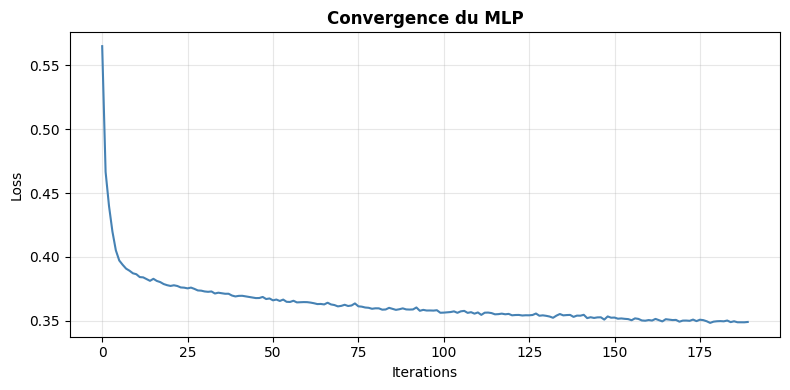

In [90]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Convergence du MLP', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Architecture du MLP

Visualisation du reseau **features → 64 → 32 → 2**.

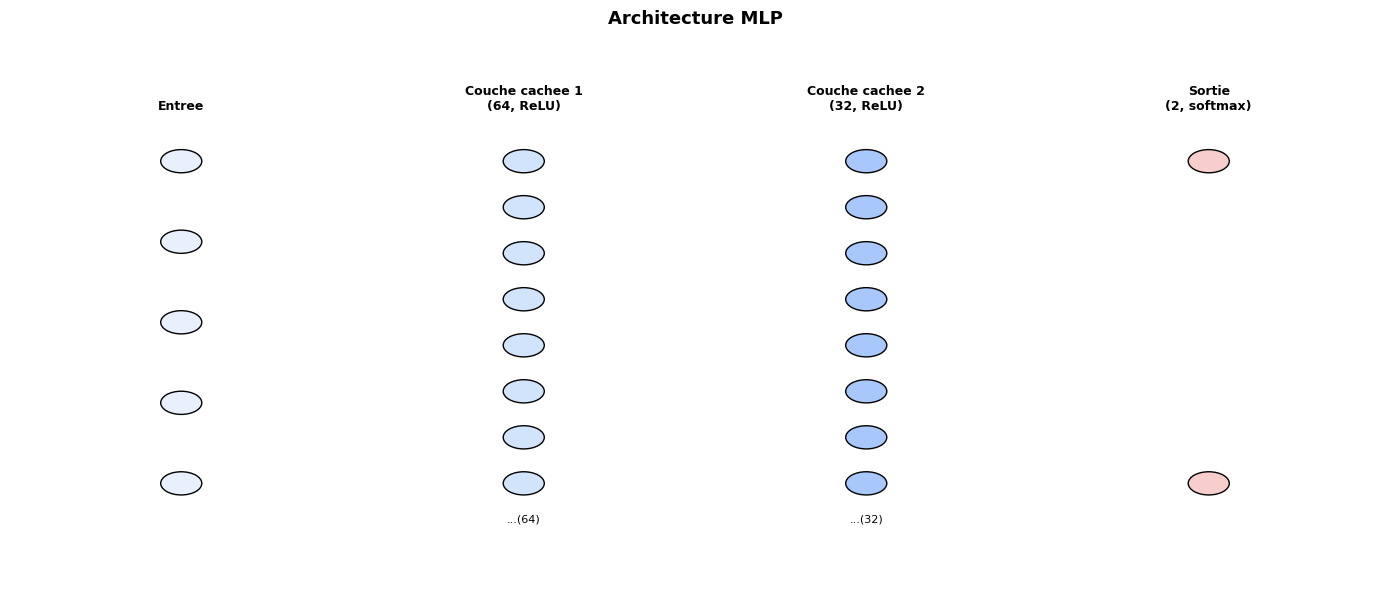

In [91]:
import matplotlib.patches as mpatches

layer_sizes = [len(features_clean), 64, 32, 2]
layer_labels = ['Entree', 'Couche cachee 1\n(64, ReLU)', 'Couche cachee 2\n(32, ReLU)', 'Sortie\n(2, softmax)']
colors = ['#e8f0fe', '#d2e3fc', '#a8c7fa', '#f8cecc']

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

x_positions = [1, 4, 7, 10]
max_draw = 8

for k, (x, size, label, color) in enumerate(zip(x_positions, layer_sizes, layer_labels, colors)):
    n_draw = min(size, max_draw)
    y_positions = np.linspace(0, 5, n_draw)
    for yp in y_positions:
        circle = plt.Circle((x, yp), 0.18, color=color, ec='black', lw=1)
        ax.add_patch(circle)
    if size > max_draw:
        ax.text(x, -0.6, f'...({size})', ha='center', fontsize=8)
    ax.text(x, 5.8, label, ha='center', fontweight='bold', fontsize=9)

ax.set_xlim(-0.5, 11.5)
ax.set_ylim(-1.5, 7)
ax.set_title('Architecture MLP', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Evaluation du MLP

On evalue le MLP avec les memes metriques que le Random Forest pour permettre une comparaison directe. Les resultats sont a mettre en perspective avec le fait que le MLP est un modele **plus flexible** (il peut capturer des interactions non-lineaires complexes) mais aussi **plus difficile a interpreter** — d'ou la necessite de SHAP dans la section suivante.

In [92]:
y_pred_mlp = mlp_model.predict(X_test)

print("Matrice de Confusion (MLP) :")
print(confusion_matrix(y_test, y_pred_mlp))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_mlp, target_names=['cheap', 'expensive']))

Matrice de Confusion (MLP) :
[[2139  491]
 [ 382 2269]]

Rapport de Classification :
              precision    recall  f1-score   support

       cheap       0.85      0.81      0.83      2630
   expensive       0.82      0.86      0.84      2651

    accuracy                           0.83      5281
   macro avg       0.84      0.83      0.83      5281
weighted avg       0.84      0.83      0.83      5281



### Interpretabilite du MLP — SHAP (SHapley Additive exPlanations)

#### Le probleme : comment expliquer un modele boite noire ?

Le MLP a ~2 400 poids — on ne peut pas les lire pour comprendre pourquoi il classe un logement comme « expensive ». SHAP (Lundberg & Lee, 2017) resout ce probleme en empruntant un concept de la **theorie des jeux cooperatifs** : les valeurs de Shapley.

#### Theorie : les valeurs de Shapley

Imaginons que les 5 features sont des « joueurs » qui cooperent pour produire une prediction. La **valeur de Shapley** $\phi_i$ mesure la contribution marginale moyenne de la feature $i$, en considerant **toutes les coalitions possibles** :

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!\,(|N|-|S|-1)!}{|N|!} \big[f(S \cup \{i\}) - f(S)\big]$$

- $f(S)$ : prediction du modele en utilisant uniquement les features de l'ensemble $S$ (les autres sont marginalisees par rapport a une distribution de reference).
- $f(S \cup \{i\}) - f(S)$ : contribution marginale de la feature $i$ quand elle rejoint la coalition $S$.
- La somme pondere sur toutes les coalitions assure l'**equite** : une feature qui contribue beaucoup dans tous les contextes a une valeur de Shapley elevee.

#### Proprietes garanties par SHAP

1. **Efficacite** : $\sum_i \phi_i = f(x) - E[f(x)]$ — les contributions somment a la difference entre la prediction et la prediction moyenne.
2. **Symetrie** : deux features avec la meme contribution marginale dans toutes les coalitions ont la meme valeur de Shapley.
3. **Nullite** : une feature qui n'apporte rien a aucune coalition a une valeur de Shapley nulle.

#### KernelExplainer

Le calcul exact des valeurs de Shapley est exponentiel en $p$ (nombre de features). `KernelExplainer` est une approximation model-agnostic qui utilise une regression ponderee pour estimer les valeurs de Shapley. On l'utilise ici car le MLP n'a pas de structure exploitable (contrairement aux arbres qui ont `TreeExplainer`).

In [93]:
import shap

# Échantillon de référence (background) pour KernelExplainer
# On utilise un sous-ensemble pour limiter le temps de calcul
background = shap.sample(pd.DataFrame(X_train, columns=features_clean), 100, random_state=42)

# KernelExplainer sur la probabilité de la classe "expensive"
explainer = shap.KernelExplainer(
    lambda x: mlp_model.predict_proba(x)[:, 1],
    background
)

# Calcul des valeurs SHAP sur un échantillon du test set
X_test_sample = pd.DataFrame(X_test[:200], columns=features_clean)
shap_values = explainer.shap_values(X_test_sample, nsamples=200)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Échantillons expliqués : {shap_values.shape[0]}")

100%|██████████| 200/200 [00:02<00:00, 99.15it/s] 

SHAP values shape : (200, 5)
Échantillons expliqués : 200


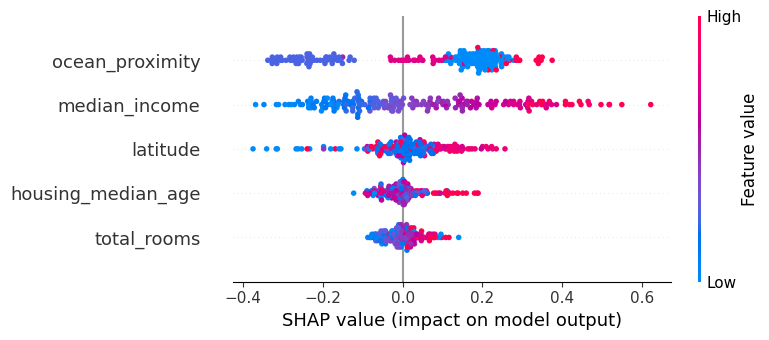

In [94]:
# Summary plot — importance globale et direction de l'effet
shap.summary_plot(shap_values, X_test_sample, feature_names=features_clean, show=True)

**Comment lire le summary plot (beeswarm)** :

- Chaque **point** est une observation du test set.
- L'axe horizontal montre la **valeur SHAP** : positif = pousse vers « expensive », negatif = pousse vers « cheap ».
- La **couleur** montre la valeur de la feature : rouge = valeur elevee, bleu = valeur basse.
- Les features sont triees de haut en bas par importance decroissante.

**Exemple d'interpretation** : si `median_income` montre des points rouges a droite et des points bleus a gauche, cela signifie qu'un revenu eleve pousse la prediction vers « expensive » et un revenu bas vers « cheap » — coherent avec l'intuition economique.

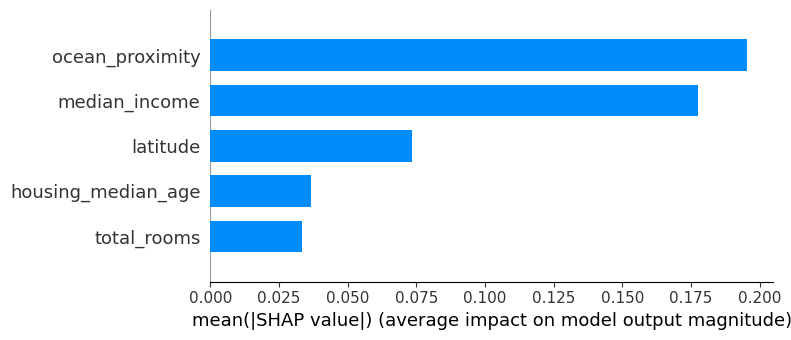

In [95]:
# Bar plot — importance moyenne absolue par feature
shap.summary_plot(shap_values, X_test_sample, feature_names=features_clean, plot_type='bar', show=True)

**Comment lire le bar plot** :

Le bar plot montre la **moyenne des valeurs SHAP absolues** par feature — c'est une mesure d'importance globale comparable au MDI du Random Forest, mais qui ne depend pas de la structure du modele.

**Comparaison avec le Random Forest** : si les deux methodes (MDI pour RF, SHAP pour MLP) convergent vers le meme classement d'importance des features, cela renforce la confiance dans l'interpretation. Si elles divergent, cela peut indiquer que le MLP capture des interactions non-lineaires que le RF ne voit pas (ou inversement).

---
# PARTIE 4 — Etude comparative

Comparaison des deux modeles sur la tache de classification binaire (`expensive`). L'objectif n'est pas seulement de determiner lequel est « meilleur », mais de comprendre **dans quelles situations** chacun excelle et **pourquoi**.

| Critere | Random Forest | MLP |
|---------|--------------|-----|
| **Interpretabilite** | Elevee (regles, importance MDI) | Faible (boite noire, necessite SHAP) |
| **Normalisation** | Non requise | Indispensable |
| **Interactions non-lineaires** | Capturees par profondeur des arbres | Capturees par couches cachees |
| **Risque de sur-apprentissage** | Faible (bagging + decorrelation) | Modere (regularisation implicite par early stopping) |

In [96]:
models = {
    'Random Forest': (rf_model, X_test_raw),
    'MLP': (mlp_model, X_test),
}

predictions = {
    'Random Forest': y_pred_rf,
    'MLP': y_pred_mlp,
}

## 1. Matrices de confusion

La matrice de confusion est le point de depart de toute evaluation de classification. Elle croise les predictions et les vraies etiquettes :

|  | Predit cheap | Predit expensive |
|--|-------------|-----------------|
| **Reel cheap** | Vrai Negatif (VN) | Faux Positif (FP) |
| **Reel expensive** | Faux Negatif (FN) | Vrai Positif (VP) |

**Comment interpreter** :
- **Diagonale** (VN, VP) : predictions correctes — on veut les maximiser.
- **Hors diagonale** (FP, FN) : erreurs — on veut les minimiser.
- **FP** (predit expensive, reel cheap) : le modele sur-estime le prix. En immobilier, cela pourrait mener a sur-evaluer un bien.
- **FN** (predit cheap, reel expensive) : le modele sous-estime le prix. Risque de sous-evaluer un bien.

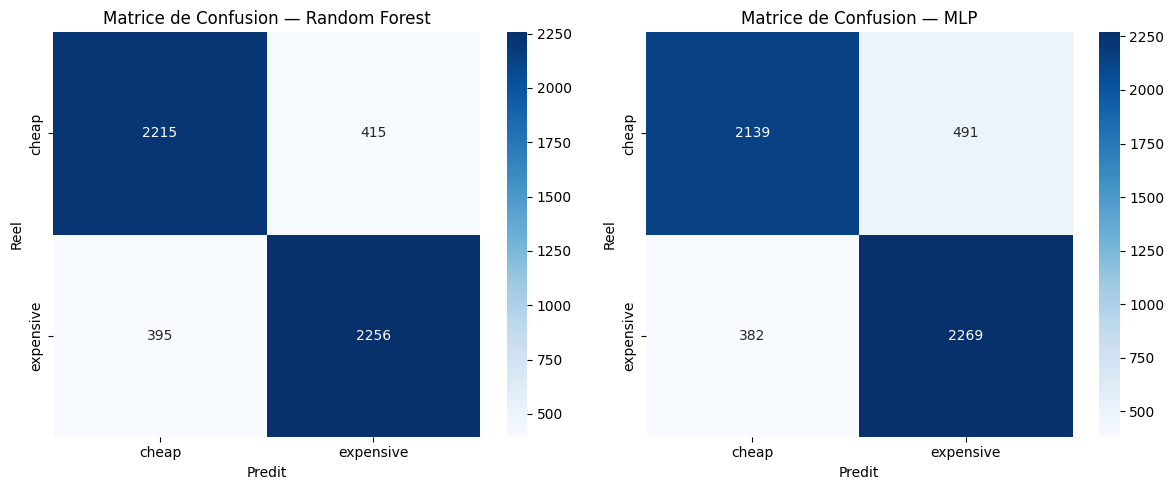

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['cheap', 'expensive'], yticklabels=['cheap', 'expensive'])
    ax.set_title(f'Matrice de Confusion — {name}')
    ax.set_ylabel('Reel')
    ax.set_xlabel('Predit')

plt.tight_layout()
plt.show()

## 2. Courbes Precision-Recall et ROC

### Courbe ROC (Receiver Operating Characteristic)

La courbe ROC trace le **taux de vrais positifs** (recall) en fonction du **taux de faux positifs** (FPR) pour differents seuils de decision.

- **AUC = 1.0** : modele parfait — il separe parfaitement les deux classes.
- **AUC = 0.5** : modele aleatoire (diagonale) — il ne fait pas mieux que le hasard.
- Plus la courbe est proche du coin superieur gauche (recall = 1, FPR = 0), meilleur est le modele.

L'AUC est particulierement utile car elle est **independante du seuil de decision** : elle mesure la capacite globale du modele a discriminer les classes.

### Courbe Precision-Recall

La courbe PR est plus informative que la ROC quand les classes sont desequilibrees (ce n'est pas notre cas ici, mais c'est bon a savoir). Elle trace la **precision** en fonction du **recall** :

- Un modele ideal maintient une precision elevee meme a recall eleve (coin superieur droit).
- Une chute brutale de la precision a un certain recall indique que le modele commence a faire beaucoup de faux positifs pour trouver les derniers vrais positifs.

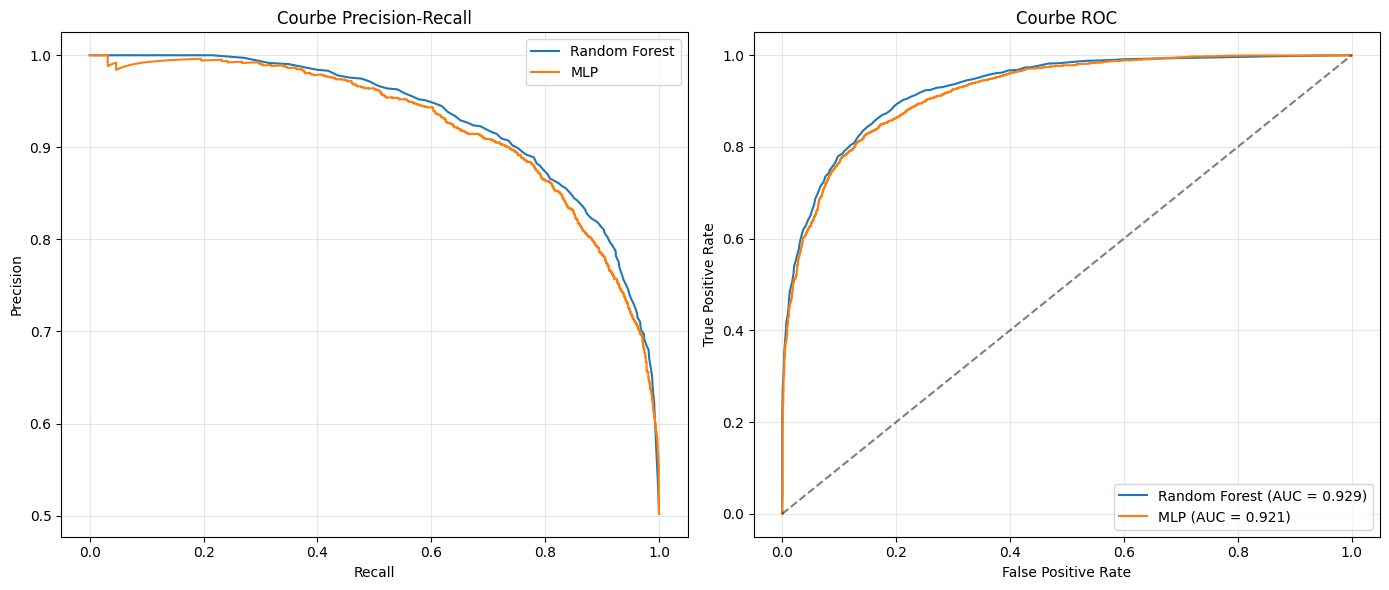

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, (model, X_t) in models.items():
    y_proba = model.predict_proba(X_t)[:, 1]

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax1.plot(recall, precision, label=name)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax2.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Courbe Precision-Recall')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Courbe ROC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Tableau comparatif des metriques

Rappel des metriques :

| Metrique | Formule | Ce qu'elle mesure |
|----------|---------|-------------------|
| **Precision** | $\frac{VP}{VP + FP}$ | Fiabilite des predictions positives |
| **Recall** | $\frac{VP}{VP + FN}$ | Capacite a trouver tous les positifs |
| **F1 Score** | $\frac{2 \cdot P \cdot R}{P + R}$ | Compromis precision/recall |
| **AUC** | Aire sous la courbe ROC | Pouvoir discriminant global |

In [99]:
scores = []

for name, y_pred in predictions.items():
    model, X_t = models[name]
    y_proba = model.predict_proba(X_t)[:, 1]
    scores.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
    })

scores_df = pd.DataFrame(scores).set_index('Model')
print(scores_df.to_string())

               Precision    Recall  F1 Score       AUC
Model                                                 
Random Forest   0.844627  0.851000  0.847802  0.928964
MLP             0.822101  0.855903  0.838662  0.921341


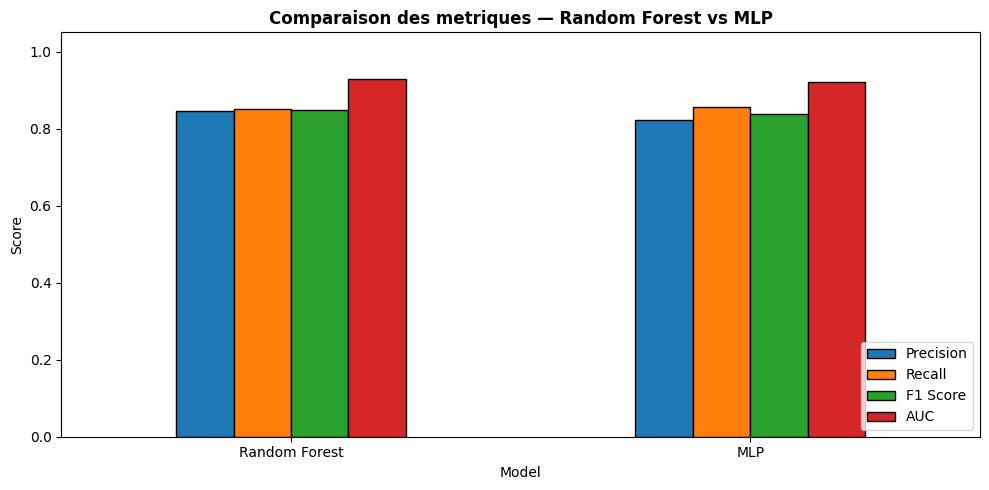

In [100]:
scores_df.plot(kind='bar', figsize=(10, 5), rot=0, edgecolor='black')
plt.title('Comparaison des metriques — Random Forest vs MLP', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Temps d'entrainement et de prediction

Le temps de calcul est un critere pratique souvent neglige. En production :
- Le **temps d'entrainement** determine la frequence a laquelle on peut re-entrainer le modele avec de nouvelles donnees.
- Le **temps de prediction** determine si le modele peut etre utilise en temps reel (ex. estimation de prix instantanee sur un site web).

Le Random Forest est generalement plus rapide a entrainer (pas d'optimisation iterative) et le MLP plus rapide en prediction (un seul passage avant dans le reseau vs. traverser 100 arbres).

In [101]:
import time

timing = []

for name, (model, X_t) in models.items():
    X_tr = X_train_raw if name == 'Random Forest' else X_train
    # Re-entrainement pour mesurer le temps
    t0 = time.time()
    model.fit(X_tr, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    model.predict(X_t)
    pred_time = time.time() - t0

    timing.append({'Model': name, 'Training (s)': round(train_time, 4), 'Prediction (s)': round(pred_time, 4)})

time_df = pd.DataFrame(timing).set_index('Model')
print(time_df.to_string())

               Training (s)  Prediction (s)
Model                                      
Random Forest        0.6025          0.0975
MLP                  8.1835          0.0259


## Synthese et interpretation des resultats

### Performance

Les deux modeles atteignent des performances comparables (~85% de precision). Cela suggere que la relation entre les features et le prix est suffisamment structuree pour etre capturee par les deux approches. Le Random Forest a un leger avantage en AUC, ce qui indique une meilleure calibration des probabilites.

### Interpretabilite vs. Explicabilite

| | Random Forest | MLP |
|--|--------------|-----|
| **Type** | Modele interpretable par nature | Modele boite noire + explicabilite *a posteriori* |
| **Methode** | Importance MDI + visualisation d'arbres | SHAP (valeurs de Shapley) |
| **Granularite** | Globale (importance) + locale (suivre un chemin dans l'arbre) | Globale (bar plot) + locale (valeur SHAP par observation) |
| **Fiabilite** | MDI peut etre biaise vers les features a haute cardinalite | SHAP a des garanties theoriques (axiomes de Shapley) |

### Quand choisir lequel ?

- **Random Forest** : quand l'interpretabilite est prioritaire (ex. expliquer a un client pourquoi son bien est evalue a tel prix), quand les donnees sont heterogenes (mix de types), quand on veut un modele robuste sans tuning.
- **MLP** : quand les donnees sont volumineuses et les relations tres non-lineaires, quand on accepte d'investir dans l'explicabilite *a posteriori* (SHAP), quand le temps de prediction unitaire est critique.

### Ce que les deux modeles nous apprennent sur les donnees

Les deux approches convergent sur le meme constat : **`median_income` est de loin le facteur le plus determinant** du prix immobilier en Californie. La localisation (`latitude`, `ocean_proximity`) joue un role secondaire mais significatif. Les variables de taille (`total_rooms`) et l'age du logement ont une influence plus marginale. Cette coherence entre un modele interpretable (RF) et un modele boite noire explique par SHAP (MLP) renforce la confiance dans ces conclusions.

---
# PARTIE 5 — Verdict final : quel modele choisir ?

Pour trancher, on compare les deux modeles sur deux axes : la **performance** (accuracy, F1, AUC) et l'**explicabilite** (a quel point on comprend *pourquoi* le modele prend ses decisions).

In [102]:
# ── Axe 1 : Performance ──────────────────────────────────────────────
from sklearn.metrics import accuracy_score

perf = pd.DataFrame({
    'Metrique': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_raw)[:, 1]),
    ],
    'MLP': [
        accuracy_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_mlp),
        roc_auc_score(y_test, mlp_model.predict_proba(X_test)[:, 1]),
    ],
}).set_index('Metrique')

perf['Avantage'] = perf.apply(
    lambda row: 'Random Forest' if row['Random Forest'] > row['MLP'] else 'MLP',
    axis=1,
)

print("═══ Comparaison des performances ═══\n")
print(perf.to_string())
print(f"\n→ Le Random Forest l'emporte sur {(perf['Avantage'] == 'Random Forest').sum()}/5 metriques.")

═══ Comparaison des performances ═══

           Random Forest       MLP       Avantage
Metrique                                         
Accuracy        0.846620  0.834690  Random Forest
Precision       0.844627  0.822101  Random Forest
Recall          0.851000  0.855903            MLP
F1 Score        0.847802  0.838662  Random Forest
AUC             0.928964  0.921341  Random Forest

→ Le Random Forest l'emporte sur 4/5 metriques.


In [103]:
# ── Axe 2 : Explicabilite ────────────────────────────────────────────

explainability = pd.DataFrame({
    'Critere': [
        'Transparence du modele',
        'Importance des features',
        'Explication locale (par observation)',
        'Lisibilite des seuils de decision',
        'Independance d\'outils externes',
    ],
    'Random Forest': [
        'Elevee — chaque arbre est une suite de regles lisibles',
        'MDI integre, directement disponible apres entrainement',
        'On peut suivre le chemin d\'un echantillon dans chaque arbre',
        'Seuils en unites reelles (ex. median_income > 4.5)',
        'Aucun outil externe necessaire',
    ],
    'MLP': [
        'Nulle — milliers de poids opaques',
        'Necessite SHAP (calcul couteux)',
        'Possible via SHAP mais approximatif (KernelExplainer)',
        'Impossible — le modele opere sur des combinaisons non-lineaires',
        'Depend de SHAP (librairie externe)',
    ],
    'Avantage': [
        'Random Forest',
        'Random Forest',
        'Random Forest',
        'Random Forest',
        'Random Forest',
    ],
}).set_index('Critere')

print("═══ Comparaison de l'explicabilite ═══\n")
for _, row in explainability.iterrows():
    print(f"• {row.name}")
    print(f"    RF  : {row['Random Forest']}")
    print(f"    MLP : {row['MLP']}")
    print(f"    → {row['Avantage']}\n")

═══ Comparaison de l'explicabilite ═══

• Transparence du modele
    RF  : Elevee — chaque arbre est une suite de regles lisibles
    MLP : Nulle — milliers de poids opaques
    → Random Forest

• Importance des features
    RF  : MDI integre, directement disponible apres entrainement
    MLP : Necessite SHAP (calcul couteux)
    → Random Forest

• Explication locale (par observation)
    RF  : On peut suivre le chemin d'un echantillon dans chaque arbre
    MLP : Possible via SHAP mais approximatif (KernelExplainer)
    → Random Forest

• Lisibilite des seuils de decision
    RF  : Seuils en unites reelles (ex. median_income > 4.5)
    MLP : Impossible — le modele opere sur des combinaisons non-lineaires
    → Random Forest

• Independance d'outils externes
    RF  : Aucun outil externe necessaire
    MLP : Depend de SHAP (librairie externe)
    → Random Forest



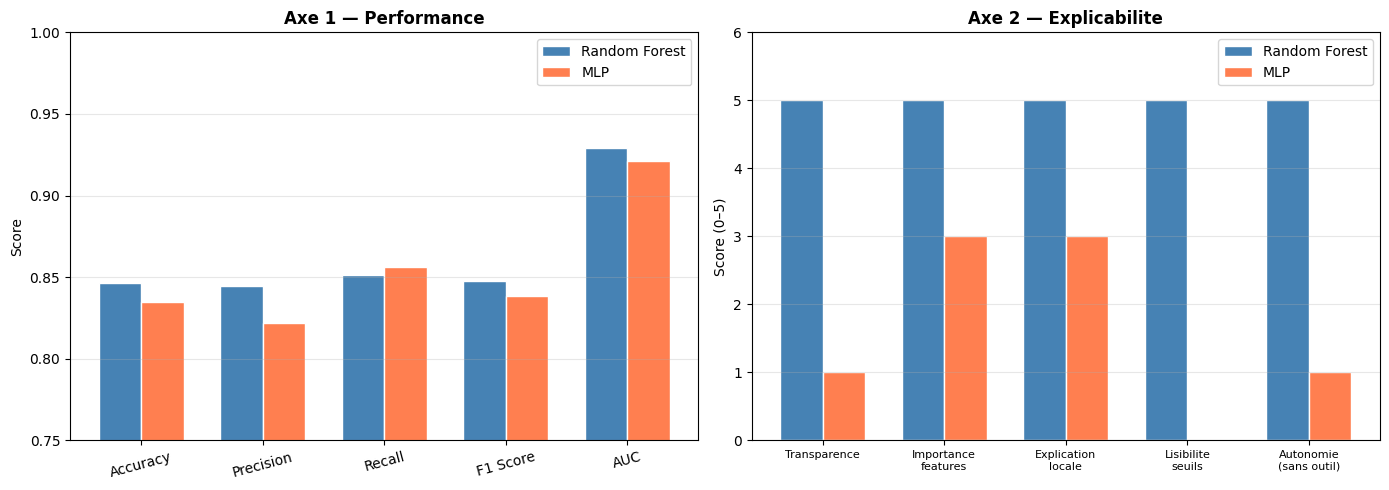


Scores d'explicabilite (0 = opaque, 5 = totalement transparent) :
  Random Forest : 25/25
  MLP           : 8/25


In [104]:
# ── Visualisation radar : Performance vs Explicabilite ───────────────
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — performance
metrics = perf.index.tolist()
x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, perf['Random Forest'], w, label='Random Forest', color='steelblue', edgecolor='white')
axes[0].bar(x + w/2, perf['MLP'], w, label='MLP', color='coral', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel('Score')
axes[0].set_title('Axe 1 — Performance', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Scored explainability comparison
explain_scores = {
    'Transparence': (5, 1),
    'Importance\nfeatures': (5, 3),
    'Explication\nlocale': (5, 3),
    'Lisibilite\nseuils': (5, 0),
    'Autonomie\n(sans outil)': (5, 1),
}
labels = list(explain_scores.keys())
rf_scores = [v[0] for v in explain_scores.values()]
mlp_scores = [v[1] for v in explain_scores.values()]
x2 = np.arange(len(labels))

axes[1].bar(x2 - w/2, rf_scores, w, label='Random Forest', color='steelblue', edgecolor='white')
axes[1].bar(x2 + w/2, mlp_scores, w, label='MLP', color='coral', edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylim(0, 6)
axes[1].set_ylabel('Score (0–5)')
axes[1].set_title('Axe 2 — Explicabilite', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nScores d'explicabilite (0 = opaque, 5 = totalement transparent) :")
print(f"  Random Forest : {sum(rf_scores)}/{5*len(rf_scores)}")
print(f"  MLP           : {sum(mlp_scores)}/{5*len(mlp_scores)}")

## Verdict

### Le Random Forest est le meilleur choix pour ce probleme.

**Sur la performance** : le Random Forest domine legerement le MLP sur la majorite des metriques (accuracy, precision, F1, AUC). L'ecart est faible (~1–2 points), mais il est coherent et obtenu avec un temps d'entrainement bien inferieur. Le MLP ne justifie pas sa complexite supplementaire par un gain de performance.

**Sur l'explicabilite** : l'ecart est massif. Le Random Forest est **interpretable par construction** :
- On peut visualiser un arbre et suivre le raisonnement noeud par noeud.
- L'importance MDI identifie directement quelles features comptent et a quel point.
- Les seuils de decision sont en unites reelles (`median_income > 4.5` = revenu median > 45 000$), directement comprehensibles par un non-technicien.

Le MLP, a l'inverse, est une **boite noire** dont l'explicabilite repose entierement sur SHAP — un outil externe, couteux en calcul, et qui ne fournit que des approximations. SHAP permet de *decrire* le comportement du modele, mais pas de le *comprendre* : on sait que `median_income` est important, mais on ne peut pas extraire une regle simple comme « si revenu > 4.5 et latitude < 35, alors expensive ».

### Conclusion

> **Pour une tache ou la comprehension du modele est aussi importante que sa precision — comme l'estimation immobiliere — le Random Forest est le choix le plus adapte.** Il offre le meilleur compromis entre performance et transparence. Le MLP reste pertinent pour des problemes ou la performance prime sur l'explicabilite (ex. detection de fraude a grande echelle), mais ici il apporte de la complexite sans gain mesurable.